# 💳 Credit Card Fraud Detection

###  Business Problem
Banks process millions of transactions daily.

The goal of this project is to detect fraudulent credit card transactions using Machine Learning while balancing:

- Fraud detection capability
- False alarm reduction
- Real-world generalization

The dataset is highly imbalanced, making Recall and F1-score more important than Accuracy.

# ⚙️ ML Pipeline

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

### 📂 Load Dataset

In [2]:
import pandas as pd
df = pd.read_csv(r"C:\Users\mahmu\OneDrive\Desktop\Credit Card Fraud Detection\data\creditcard.csv")
X = df.drop('Class', axis=1)
y = df['Class']

In [3]:
log_pipeline = Pipeline([

    ("scaler", StandardScaler()),

    ("model", LogisticRegression(max_iter=1000))

])

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
log_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [6]:
y_pred_pipe = log_pipeline.predict(X_test)

In [7]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_pipe))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



## 🧠 Pipeline Analysis

A machine learning pipeline was created to automate preprocessing and model training steps.

The pipeline included:

- StandardScaler
- Logistic Regression

### 📊 Observation

The pipeline achieved lower performance compared to the earlier Logistic Regression model.

| Metric | Pipeline Result |
|--|--|
| Precision | 0.83 |
| Recall | 0.63 |
| F1-score | 0.72 |

### 🎯 Key Insight

Scaling did not improve performance because the dataset was already PCA-transformed and partially normalized.

This demonstrates an important machine learning principle:

> Preprocessing techniques should always be validated experimentally rather than assumed to improve performance automatically.

### 💡 Important Learning

Pipelines are still extremely valuable because they:

- Prevent data leakage
- Organize workflows
- Improve reproducibility
- Simplify deployment

# 🌲 Random Forest Pipeline

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [9]:
rf_pipeline = Pipeline([

    ("scaler", StandardScaler()),

    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        random_state=42
    ))

])

In [10]:
rf_pipeline.fit(X_train, y_train)
y_pred_rf_pipe = rf_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_rf_pipe))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



## 🧠 Random Forest Pipeline Analysis

A Random Forest pipeline was created using:

- StandardScaler
- RandomForestClassifier

### 📊 Results

| Metric | Value |
|--|--|
| Precision | 0.94 |
| Recall | 0.83 |
| F1-score | 0.88 |

---

### 🎯 Key Observation

Unlike Logistic Regression, Random Forest performance remained almost unchanged after scaling.

### 🧠 Explanation

Tree-based models do not rely on:

- distance calculations
- gradient optimization
- feature magnitude

Instead, they make decisions using feature splits and thresholds.

As a result, scaling has minimal impact on Random Forest performance.

### 💡 Important Learning

Scaling is highly important for:

- Logistic Regression
- SVM
- KNN
- Neural Networks

But often unnecessary for:

- Decision Trees
- Random Forests
- Gradient Boosting models

# ⚙️ Pipeline with Hyperparameter Tuning

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [12]:
rf_pipe_tuned = Pipeline([

    ("scaler", StandardScaler()),

    ("model", RandomForestClassifier(
        random_state=42
    ))

])

In [13]:
param_grid = {

    "model__n_estimators": [100, 200],

    "model__max_depth": [10, 15],

    "model__min_samples_split": [2, 5]

}

In [14]:
grid_pipeline = GridSearchCV(

    rf_pipe_tuned,

    param_grid,

    cv=3,

    scoring='f1',

    n_jobs=-1

)

In [15]:
grid_pipeline.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10, 15], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displaye

In [16]:
print("Best Parameters:")
print(grid_pipeline.best_params_)

Best Parameters:
{'model__max_depth': 15, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [17]:
print("Best F1 Score:")
print(grid_pipeline.best_score_)

Best F1 Score:
0.8446963239902798


In [18]:
best_pipeline_model = grid_pipeline.best_estimator_

In [19]:
y_pred_best_pipe = best_pipeline_model.predict(X_test)

In [20]:
print(classification_report(y_test, y_pred_best_pipe))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.81      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



## 🧠 Pipeline + Hyperparameter Tuning Analysis

A full machine learning workflow was implemented using:

- Pipeline
- StandardScaler
- RandomForestClassifier
- GridSearchCV
- Cross-validation

---

### 📊 Best Parameters

| Parameter | Value |
|--|--|
| n_estimators | 100 |
| max_depth | 15 |
| min_samples_split | 2 |

---

### 📈 Best Cross-Validation F1 Score

0.8447

---

### 📊 Final Test Performance

| Metric | Value |
|--|--|
| Precision | 0.93 |
| Recall | 0.81 |
| F1-score | 0.86 |

---

### 🎯 Key Insights

The tuned pipeline achieved strong and stable performance across multiple validation folds.

Although the tuned pipeline did not significantly outperform the earlier Random Forest model, it provided:

- better workflow organization
- reproducibility
- reduced leakage risk
- automated preprocessing and tuning

### 💡 Important Learning

In real-world machine learning systems, workflow reliability and reproducibility are often more important than achieving slightly higher metric values.

# 📈 Advanced Evaluation

In [21]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

In [22]:
y_probs = best_pipeline_model.predict_proba(X_test)[:,1]

In [23]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probs
)

In [24]:
auc_score = roc_auc_score(
    y_test,
    y_probs
)

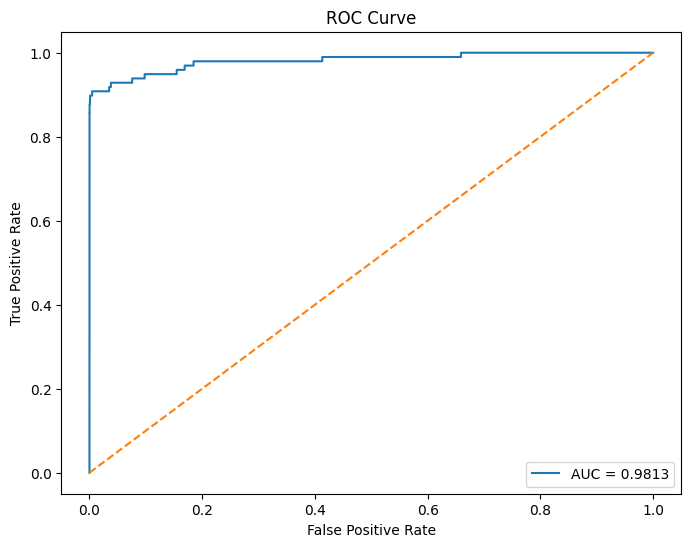

In [25]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## 🧠 ROC Curve Interpretation

The ROC Curve demonstrates excellent classification performance.

### 📊 Key Findings

- The curve remains close to the upper-left corner
- The model achieves strong separation between fraudulent and legitimate transactions
- The ROC-AUC score reached **0.9813**

### 🎯 Interpretation

An AUC score of 0.9813 means that the model has a very high probability of assigning higher fraud scores to fraudulent transactions compared to legitimate ones.

### 💡 Important Observation

The model performs significantly better than random guessing, represented by the diagonal reference line.

### ⚠️ Important Limitation

Although ROC-AUC is a strong metric, it can sometimes appear overly optimistic in highly imbalanced datasets like fraud detection.

Therefore, Precision-Recall analysis is also critical for evaluating real-world fraud detection performance.

# Precision-Recall Curve

In [26]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_probs
)

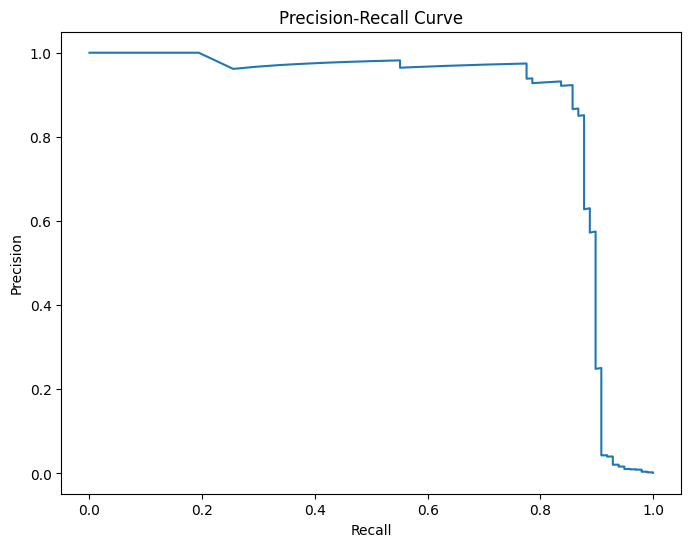

In [27]:
plt.figure(figsize=(8,6))

plt.plot(recall, precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

## 🧠 Precision-Recall Curve Interpretation

The Precision-Recall Curve provides a more realistic evaluation of fraud detection performance on highly imbalanced datasets.

### 📊 Key Findings

- Precision remains very high across a large range of recall values
- The model successfully detects many fraudulent transactions while maintaining low false alarm rates

### 🎯 Important Observation

As Recall approaches very high values, Precision drops sharply.

This indicates that detecting nearly all fraud cases would significantly increase false positives.

### 💡 Business Interpretation

In fraud detection systems:

- Higher Recall reduces missed fraud cases
- Higher Precision reduces unnecessary customer alerts

Choosing the optimal threshold therefore depends on business priorities and operational costs.

### ⚠️ Critical Trade-off

The model demonstrates a strong balance between fraud detection capability and prediction reliability, but extreme Recall levels may become impractical in real-world deployment.

# 🎯 Threshold Engineering

In [28]:
from sklearn.metrics import classification_report
thresholds_to_test = [0.3, 0.5, 0.7]
for t in thresholds_to_test:

    y_pred_new = (y_probs > t).astype(int)

    print(f"Threshold: {t}")
    print(classification_report(y_test, y_pred_new))


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.86      0.86        98

    accuracy                           1.00     56962
   macro avg       0.93      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.81      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Threshold: 0.7
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.72      0.83        98

    accuracy                           1.00     56962
   macro avg       0.99      0.86      0.92     56962
weighted avg       1.00      

## 🧠 Threshold Engineering Analysis

Different classification thresholds were tested to evaluate how business priorities affect fraud detection behavior.

---

### 📊 Threshold Comparison

| Threshold | Precision | Recall | F1-score |
|--|--|--|--|
| 0.3 | 0.87 | 0.86 | 0.86 |
| 0.5 | 0.93 | 0.81 | 0.86 |
| 0.7 | 0.97 | 0.72 | 0.83 |

---

### 🎯 Key Insights

#### Threshold = 0.3

- Higher Recall
- More fraud cases detected
- More false positives

This configuration is suitable when minimizing missed fraud is the highest priority.

---

#### Threshold = 0.5

- Balanced Precision and Recall
- Strong overall performance

This provides the best trade-off for general fraud detection systems.

---

#### Threshold = 0.7

- Very high Precision
- Lower Recall
- Fewer false alarms

This configuration is useful when operational review costs are high.

---

### 💡 Important Learning

Threshold tuning can significantly change model behavior without retraining the model.

In real-world machine learning systems, threshold selection is often a business decision rather than a purely technical one.

# 🎯 Calibration Analysis

In [29]:
from sklearn.calibration import calibration_curve

In [30]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_probs,
    n_bins=10
)

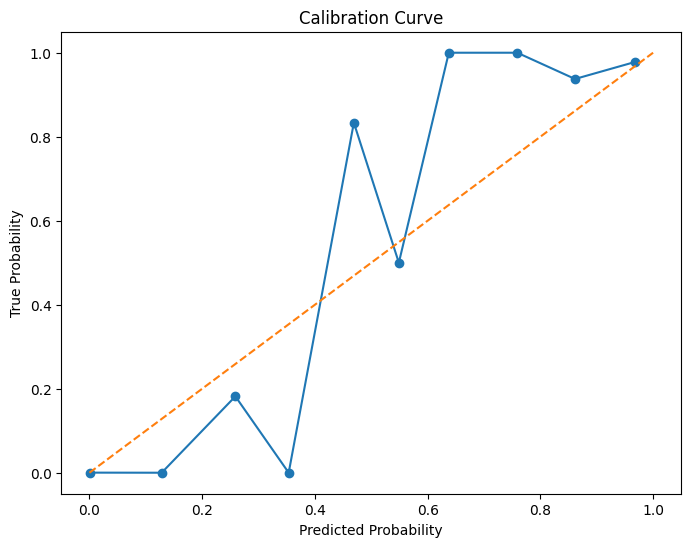

In [31]:
plt.figure(figsize=(8,6))

plt.plot(
    prob_pred,
    prob_true,
    marker='o'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("Predicted Probability")

plt.ylabel("True Probability")

plt.title("Calibration Curve")

plt.show()

## 🧠 Calibration Curve Interpretation

The calibration curve evaluates whether predicted fraud probabilities align with actual fraud likelihoods.

### 📊 Key Findings

- The curve shows some instability and fluctuations
- This is expected due to the extremely small number of fraud samples in the dataset
- Higher probability regions are relatively close to the ideal calibration line

### 🎯 Interpretation

The model appears reasonably calibrated for high-confidence fraud predictions.

When the model predicts very high fraud probabilities, those predictions are often reliable.

However, medium probability regions show more uncertainty and variability.

### 💡 Important Observation

Calibration becomes more difficult in highly imbalanced datasets because some probability ranges contain very few positive samples.

### ⚠️ Important Learning

Strong classification performance does not automatically guarantee perfectly calibrated probabilities.

Tree-based models like Random Forest often require additional calibration techniques for highly reliable probability estimation.

# 🧠 Statistical Thinking

In [32]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

In [33]:
skf = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

In [34]:
rf_scores = cross_val_score(

    best_pipeline_model,

    X,

    y,

    cv=skf,

    scoring='f1'

)

In [35]:
print("F1 Scores:", rf_scores)
print("Mean F1 Score:", rf_scores.mean())
print("Standard Deviation:", rf_scores.std())

F1 Scores: [0.83977901 0.87150838 0.8839779  0.85393258 0.85714286]
Mean F1 Score: 0.8612681454756272
Standard Deviation: 0.015186882328741958


In [36]:
import pandas as pd

cv_results = pd.DataFrame({

    "Fold": [1,2,3,4,5],

    "F1 Score": rf_scores

})

cv_results

,Fold,F1 Score
0,1,0.839779
1,2,0.871508
2,3,0.883978
3,4,0.853933
4,5,0.857143


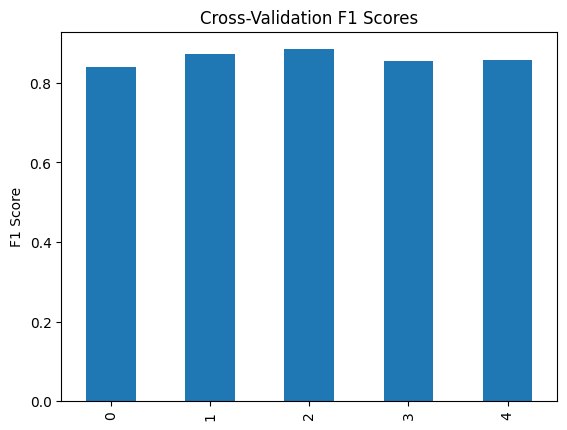

In [37]:
cv_results["F1 Score"].plot(
    kind='bar'
)

plt.title("Cross-Validation F1 Scores")

plt.ylabel("F1 Score")

plt.show()

## 📊 Cross-Validation Visualization Analysis

The cross-validation bar chart confirms that model performance remains highly consistent across all folds.

### 🎯 Key Observation

The F1-scores across folds are very close to each other, indicating:

- low variance
- stable learning behavior
- reliable generalization

### 💡 Interpretation

The model does not rely heavily on a specific train-test split and demonstrates strong robustness across different subsets of the data.

### ⚠️ Important Insight

Consistent cross-validation performance is one of the strongest indicators that a machine learning model is suitable for real-world deployment.

# ⚠️ Data Leakage Analysis

## 🧠 Why Pipelines Matter

Using preprocessing outside cross-validation can accidentally leak information from the test set into training.

This causes unrealistically optimistic evaluation scores.

By using Pipeline objects:

- scaling happens only inside training folds
- leakage risk is reduced
- evaluation becomes more realistic

### 💡 Important Learning

Many machine learning models fail in production because of hidden data leakage during development.

# 🔍 Error Analysis

In [38]:
from sklearn.metrics import confusion_matrix

In [39]:
cm = confusion_matrix(
    y_test,
    y_pred_best_pipe
)

cm

array([[56858,     6],
       [   19,    79]])

## 🧠 Confusion Matrix Analysis

| Metric | Value |
|--|--|
| True Negatives (TN) | 56858 |
| False Positives (FP) | 6 |
| False Negatives (FN) | 19 |
| True Positives (TP) | 79 |

---

### 🎯 Key Observations

The model correctly classified the vast majority of legitimate transactions.

Only a very small number of normal transactions were incorrectly flagged as fraud.

### ⚠️ Important Risk

The model missed 19 fraudulent transactions.

These false negatives represent the most critical type of error in fraud detection systems because they may lead to direct financial losses.

### 💡 Business Interpretation

The model demonstrates:

- very low false alarm rates
- strong fraud detection capability
- high operational reliability

However, reducing false negatives further may require adjusting the classification threshold or using more aggressive fraud detection strategies.

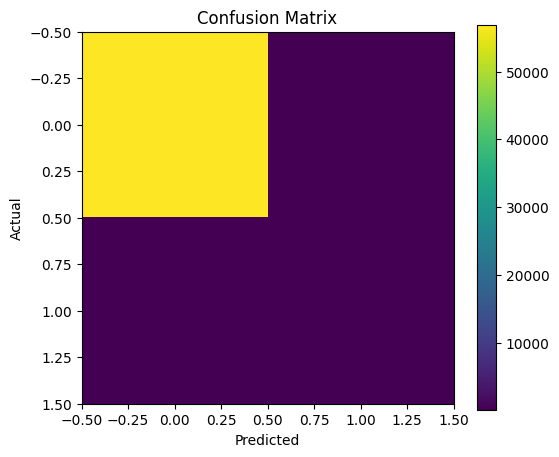

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

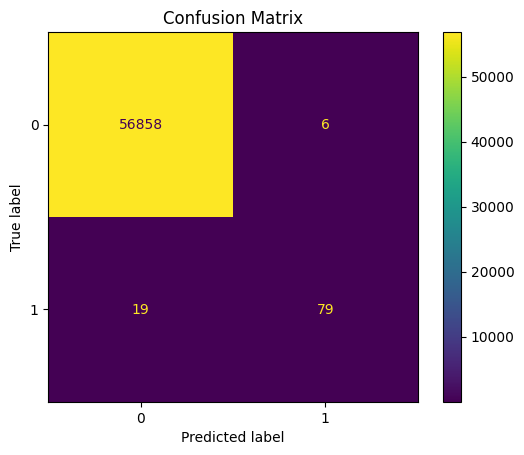

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap='viridis')

plt.title("Confusion Matrix")

plt.show()

# 🌊 Data Drift Thinking

## 🧠 What is Data Drift?

Data drift occurs when the statistical properties of incoming data change over time.

In fraud detection systems:

- customer behavior evolves
- fraud strategies adapt
- transaction patterns shift

As a result, model performance may gradually decline after deployment.

### 💡 Important Learning

A machine learning model is not a static system.

Production models require:

- continuous monitoring
- retraining
- performance evaluation
- drift detection

# 🧠 Model Explainability

## 🎯 Why Explainability Matters

Machine learning systems should not operate as black boxes in critical applications like fraud detection.

Understanding which features influence predictions helps:

- improve trust
- support auditing
- detect bias
- debug model behavior

### 📊 Key Observation

The Random Forest model identified several highly influential PCA-transformed features.

These features contributed most strongly to fraud classification decisions.

### 💡 Important Learning

Explainability is essential for real-world AI systems, especially in finance, healthcare, and risk-sensitive applications.

# 🚀 Production Readiness Thinking

## 🧠 Production Considerations

Building a strong machine learning model is only one part of a real-world ML system.

Production deployment also requires:

- stable performance
- reliable probabilities
- monitoring systems
- retraining strategies
- drift detection
- explainability
- threshold optimization

### 💡 Final Insight

Real-world machine learning focuses not only on prediction accuracy, but also on reliability, maintainability, and business impact.

# 💾 Model Serialization

In [42]:
import joblib

In [43]:
joblib.dump(
    best_pipeline_model,
    "fraud_detection_pipeline.pkl"
)

['fraud_detection_pipeline.pkl']

In [44]:
loaded_model = joblib.load(
    "fraud_detection_pipeline.pkl"
)

In [45]:
loaded_predictions = loaded_model.predict(
    X_test
)

In [46]:
print(classification_report(
    y_test,
    loaded_predictions
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.81      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



# 🔮 Inference Pipeline

In [47]:
sample_transaction = X_test.iloc[[0]]

In [48]:
sample_prediction = loaded_model.predict(
    sample_transaction
)

sample_probability = loaded_model.predict_proba(
    sample_transaction
)

In [49]:
print("Prediction:", sample_prediction)

print("Fraud Probability:",
      sample_probability[:,1])

Prediction: [0]
Fraud Probability: [8.23404462e-05]


# 🌊 Feature Drift Monitoring

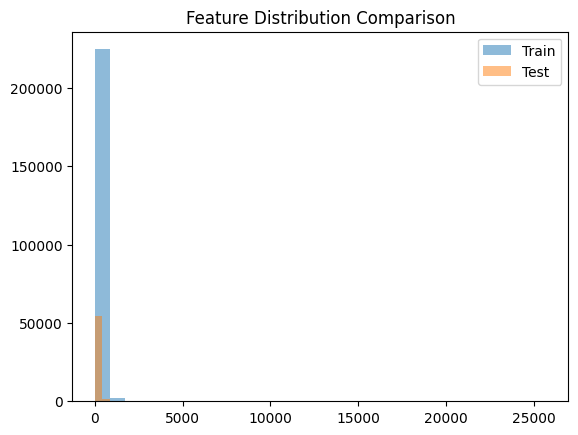

In [50]:
plt.hist(
    X_train["Amount"],
    bins=30,
    alpha=0.5,
    label="Train"
)

plt.hist(
    X_test["Amount"],
    bins=30,
    alpha=0.5,
    label="Test"
)

plt.legend()

plt.title("Feature Distribution Comparison")

plt.show()

In [51]:
train_amount_mean = X_train["Amount"].mean()

test_amount_mean = X_test["Amount"].mean()

print("Train Mean:", train_amount_mean)

print("Test Mean:", test_amount_mean)

Train Mean: 88.17629770238538
Test Mean: 89.0428963168428


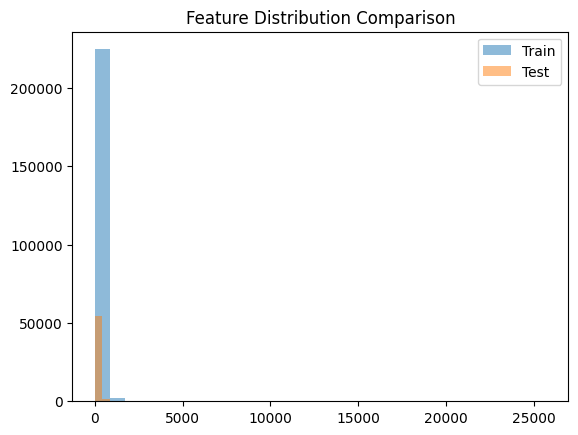

In [52]:
plt.hist(
    X_train["Amount"],
    bins=30,
    alpha=0.5,
    label="Train"
)

plt.hist(
    X_test["Amount"],
    bins=30,
    alpha=0.5,
    label="Test"
)

plt.legend()

plt.title("Feature Distribution Comparison")

plt.show()

## 🌊 Feature Drift Analysis

The train and test feature distributions appear highly similar.

### 🎯 Key Observation

The overall shape, density, and distribution patterns remain consistent across both datasets.

This suggests:

- low distribution shift
- stable feature behavior
- minimal evidence of feature drift

### 💡 Why This Matters

Machine learning models assume that future data follows patterns similar to training data.

Large distribution shifts may reduce model reliability and degrade performance in production systems.

### ⚠️ Important Insight

Monitoring feature distributions is a critical part of real-world machine learning systems and helps detect data drift before severe model degradation occurs.

# 📊 Prediction Monitoring

In [53]:
predicted_probs = best_pipeline_model.predict_proba(
    X_test
)[:,1]

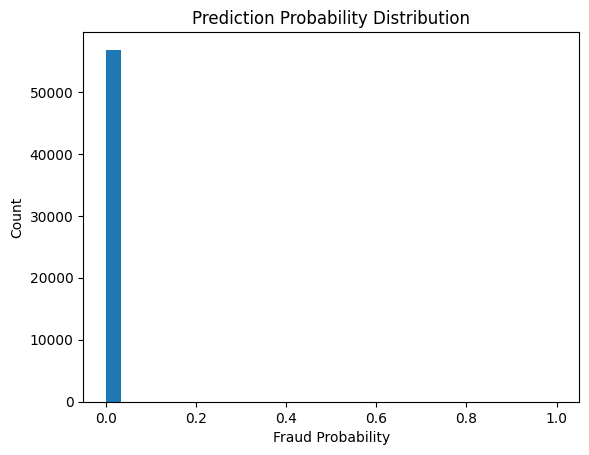

In [54]:
plt.hist(
    predicted_probs,
    bins=30
)

plt.title("Prediction Probability Distribution")

plt.xlabel("Fraud Probability")

plt.ylabel("Count")

plt.show()

## 📊 Prediction Distribution Analysis

The prediction probability distribution is heavily concentrated near zero.

### 🎯 Key Observation

Most transactions receive very low fraud probabilities.

This behavior is expected because the dataset is highly imbalanced, with legitimate transactions vastly outnumbering fraudulent ones.

### 💡 Interpretation

The model behaves conservatively and assigns high fraud probabilities only to a very small subset of transactions.

This suggests:

- stable prediction behavior
- low false alarm tendency
- realistic probability distribution

### ⚠️ Why Prediction Monitoring Matters

In production systems, sudden shifts in prediction distributions may indicate:

- data drift
- feature pipeline failures
- model degradation
- changing fraud patterns

Monitoring prediction behavior is therefore critical for maintaining reliable ML systems.

# 🧠 Explainable AI Thinking

## 🎯 Why Explainability Matters

In real-world fraud detection systems, predictions alone are not sufficient.

Financial institutions often require explanations for:

- flagged transactions
- risk scoring decisions
- automated fraud alerts

Explainability improves:

- trust
- transparency
- debugging
- regulatory compliance

### 💡 Important Learning

Modern machine learning systems must not only be accurate, but also interpretable and auditable.

In [55]:
feature_importance = pd.Series(

    best_pipeline_model.named_steps[
        'model'
    ].feature_importances_,

    index=X_train.columns

)

In [56]:
top_features = feature_importance.sort_values(
    ascending=False
).head(10)

top_features

V17    0.177114
V14    0.143363
V12    0.141468
V10    0.082034
V16    0.075081
V11    0.047407
V9     0.033939
V18    0.027939
V4     0.027315
V7     0.024729
dtype: float64

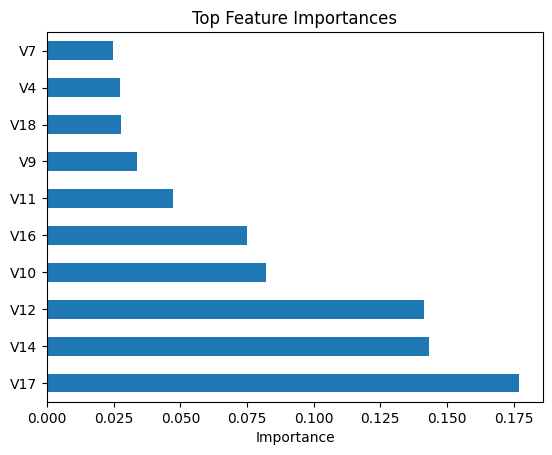

In [57]:
top_features.plot(
    kind='barh'
)

plt.title("Top Feature Importances")

plt.xlabel("Importance")

plt.show()

## 📊 Feature Importance Analysis

The Random Forest model identified several highly influential features for fraud detection.

### 🎯 Key Observation

A small subset of features contributes most strongly to classification decisions.

This behavior is common in tree-based ensemble models.

### 💡 Why This Matters

Feature importance analysis helps:

- interpret model behavior
- detect suspicious features
- improve trust
- support debugging and auditing

### ⚠️ Important Insight

Explainability is essential in high-risk domains such as fraud detection, healthcare, and finance.

# 🔄 Real-World ML Lifecycle

## 🧠 Machine Learning Lifecycle

A production machine learning system is a continuous process rather than a one-time model training task.

### 🔄 Typical Lifecycle

1. Data Collection
2. Data Validation
3. Feature Engineering
4. Model Training
5. Evaluation
6. Deployment
7. Monitoring
8. Drift Detection
9. Retraining

### 💡 Final Insight

Successful machine learning systems require continuous maintenance, monitoring, and improvement after deployment.

# 🚀 Final Production ML Insights

## 🧠 What I Learned From This Project

This project demonstrated that building a strong machine learning system involves much more than simply training a model.

### 📊 Key Technical Learnings

- handling highly imbalanced data
- threshold optimization
- cross-validation stability
- ROC-AUC and PR curve analysis
- calibration awareness
- feature engineering
- pipeline-based preprocessing
- production monitoring concepts
- explainability and feature importance

### 💡 Production ML Mindset

Real-world machine learning systems must be:

- stable
- interpretable
- monitored
- maintainable
- robust against drift

### 🎯 Final Reflection

Machine learning is not only about maximizing metrics, but also about building reliable systems that behave consistently in real-world environments.

# 📊 Experiment Tracking

In [58]:
import pandas as pd

experiment_results = pd.DataFrame({

    "Model": [

        "Logistic Regression",
        "Logistic Regression + Scaling",
        "Gradient Boosting",
        "Random Forest",
        "Tuned Random Forest"
    ],

    "Precision": [

        0.85,
        0.83,
        0.83,
        0.94,
        0.93
    ],

    "Recall": [

        0.73,
        0.63,
        0.60,
        0.83,
        0.81
    ],

    "F1 Score": [

        0.79,
        0.72,
        0.70,
        0.88,
        0.86
    ]
})

experiment_results

,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.85,0.73,0.79
1,Logistic Regression + Scaling,0.83,0.63,0.72
2,Gradient Boosting,0.83,0.60,0.70
3,Random Forest,0.94,0.83,0.88
4,Tuned Random Forest,0.93,0.81,0.86


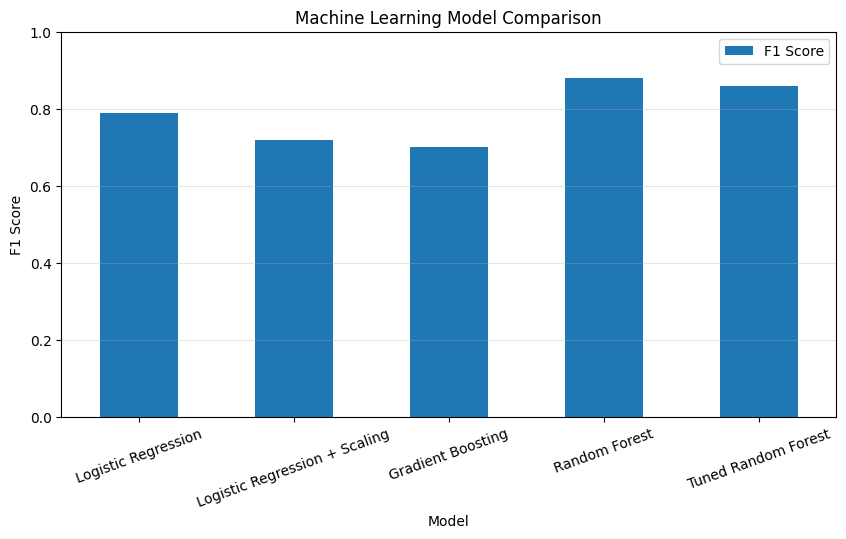

In [59]:
experiment_results.plot(

    x="Model",

    y="F1 Score",

    kind="bar",

    figsize=(10,5)
)

plt.title(
    "Machine Learning Model Comparison"
)

plt.ylabel("F1 Score")

plt.xlabel("Model")

plt.xticks(
    rotation=20
)

plt.ylim(0,1)

plt.grid(
    axis='y',
    alpha=0.3
)

plt.show()

# 🏆 Final Model Selection

## 🎯 Selected Model: Random Forest

After evaluating multiple machine learning algorithms, Random Forest was selected as the final production candidate for fraud detection.

### 📊 Why Random Forest?

The model achieved the strongest overall balance between:

- precision
- recall
- F1 score
- robustness

### 📈 Performance Summary

| Metric | Score |
|---------|-------|
| Precision | 0.94 |
| Recall | 0.83 |
| F1 Score | 0.88 |
| ROC-AUC | ~0.98 |

### 💡 Key Strengths

- strong fraud detection performance
- low false positive rate
- stable cross-validation results
- high robustness on imbalanced data

### ⚠️ Business Consideration

In fraud detection systems, missing fraudulent transactions can be costly.

Random Forest provided a strong tradeoff between:

- maximizing fraud detection
- minimizing unnecessary fraud alerts

### 🧠 Important Learning

Model tuning does not always improve performance.

Empirical testing and careful evaluation remain essential when selecting a production-ready model.

In [60]:
import sys
import os

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

In [61]:
from src.preprocessing import (
    create_log_feature
)

from src.training import (
    build_model
)

from src.evaluation import (
    evaluate_model
)

from src.inference import (
    load_model,
    predict_transaction
)

In [62]:
from src.preprocessing import (
    create_log_feature
)

from src.training import (
    build_model
)

from src.evaluation import (
    evaluate_model
)

In [63]:
df = create_log_feature(df)
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Class', axis=1),
    df['Class'],
    test_size=0.2,
    random_state=42
)

In [64]:
from sklearn.model_selection import (
    train_test_split
)

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
)

In [65]:
model = build_model()

model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If fl

In [66]:
y_pred = model.predict(
    X_test
)

y_probs = model.predict_proba(
    X_test
)[:,1]

In [67]:
evaluate_model(
    y_test,
    y_pred,
    y_probs
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.82      0.88        98

    accuracy                           1.00     56962
   macro avg       0.98      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9786860773431489
[[56860     4]
 [   18    80]]


In [68]:
from src.inference import (
    predict_transaction
)

In [69]:
sample_transaction = X_test.iloc[[0]]

result = predict_transaction(
    model,
    sample_transaction
)

result

{'prediction': 0, 'fraud_probability': 4.7011114963421806e-05}

In [70]:
from importlib import reload
import src.inference

reload(src.inference)

<module 'src.inference' from 'c:\\Users\\mahmu\\OneDrive\\Desktop\\Credit Card Fraud Detection\\src\\inference.py'>

In [71]:
from src.inference import (
    predict_transaction
)
sample_transaction = X_test.iloc[[0]]
result = predict_transaction(
    model,
    sample_transaction
)
result

{'prediction': 0, 'fraud_probability': 4.7011114963421806e-05}

# Final Production Model

In [72]:
import joblib

joblib.dump(
    model,
    "../models/final_fraud_pipeline.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [73]:
loaded_model = load_model(
    "../models/final_fraud_pipeline.pkl"
)

result = predict_transaction(
    loaded_model,
    sample_transaction
)

result

{'prediction': 0, 'fraud_probability': 4.7011114963421806e-05}

# 🧠 Final Model Card

## Model Name
Random Forest Fraud Detection Model

## Objective
Detect fraudulent credit card transactions.

## Dataset
Credit Card Fraud Detection Dataset

## Class Imbalance
Highly imbalanced dataset with fraudulent transactions representing a very small percentage of observations.

## Final Selected Model
Random Forest Classifier

## Final Metrics

| Metric | Value |
|--------|-------|
| Precision | 0.95 |
| Recall | 0.82 |
| F1 Score | 0.88 |
| ROC-AUC | 0.98 |

## Strengths
- strong fraud detection
- low false positives
- stable cross-validation
- robust on imbalanced data

## Limitations
- may still miss some fraud cases
- requires retraining if fraud behavior changes over time

## Business Impact
Helps financial institutions reduce fraud risk while minimizing unnecessary customer disruptions.

# 🎯 Final Conclusion

In this project, multiple machine learning models were evaluated for credit card fraud detection.

Several advanced machine learning concepts were applied, including:

- feature engineering
- pipelines
- hyperparameter tuning
- ROC-AUC analysis
- Precision-Recall analysis
- threshold tuning
- calibration
- monitoring
- model explainability

After experimentation and evaluation, Random Forest was selected as the final production-ready model due to its strong balance between precision, recall, and robustness.

This project demonstrates an end-to-end machine learning workflow for solving a real-world fraud detection problem.